Questionnement en tout genre : 
comment on traite les NA ?
Est ce qu'on fait bien set.seed et separation train test ? 

# Pretraitement et modelisation par scenarios

Ce notebook prolonge directement `02_eda.ipynb`. Il formalise la phase de pretraitement puis compare plusieurs scenarios de modelisation de facon rigoureuse, en separant :
- le choix de la cible (`multiclasse` contre `binaire`) ;
- le choix du jeu de variables (`conservateur` contre `etendu`) ;
- le choix du modele (`Dummy`, `Logistic Regression`, `Random Forest`).

Les comparaisons reposent principalement sur des metriques de discrimination (`AUC`), des metriques de classification (`accuracy`, `balanced accuracy`, `F1`) et, pour les modeles logistiques, sur des criteres d'information (`AIC`, `BIC`).


## 1. Interpretation synthetique de l'EDA precedente

L'EDA du notebook `02_eda.ipynb` met en evidence plusieurs points decisifs pour la suite du projet.

### 1. Une cible multiclasse vraiment exploitable

La reconstruction a partir des fichiers locaux aboutit a une cible `num` distribuee en `411` observations pour la classe `0`, `196` pour la classe `1`, `135` pour la classe `2`, `135` pour la classe `3` et `43` pour la classe `4`. La classe `4` reste rare, mais les classes intermediaires ont un effectif suffisant pour justifier une vraie evaluation multiclasse.

### 2. Une forte heterogeneite entre sources

Les hopitaux n'ont pas du tout le meme profil. Hungary est majoritairement composee de cas `num = 0`, alors que Switzerland contient tres peu de patients sains. VA Long Beach presente elle aussi davantage de cas positifs que Cleveland. Cette heterogeneite rend la fusion pertinente, mais elle impose de rester prudent sur l'interpretation des performances globales.

### 3. Des problemes de qualite de donnees tres concentres

Trois variables ressortent comme critiques : `ca`, `thal` et `slope`, avec respectivement environ `66 %`, `52 %` et `34 %` de valeurs manquantes. Le manque d'information est tres asymetrique selon la source, ce qui laisse penser qu'un simple pretraitement uniforme serait insuffisant.

### 4. Des signaux cliniques utiles sont deja visibles

L'EDA montre des associations plausibles entre la cible et plusieurs covariables : baisse de `thalach` quand la severite augmente, hausse de `oldpeak`, poids important de `cp = 4` et de `exang = 1`, ainsi qu'un signal potentiel de `ca`, `slope` et `thal`. Cela motive la comparaison entre un scenario conservateur, plus robuste, et un scenario etendu, potentiellement plus informatif mais plus fragile.

### 5. Une consequence methodologique claire

La suite logique est donc de comparer explicitement plusieurs scenarios, plutot que d'imposer d'emblee une seule cible ou un seul ensemble de variables. C'est exactement l'objectif du present notebook.


## 2. Import des bibliotheques


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11


## 3. Rechargement de la base a partir des fichiers locaux

On reprend ici la logique du notebook `02_eda.ipynb` : lecture prioritaire des fichiers bruts UCI, avec fallback documente sur `processed.cleveland.data` car le fichier brut `cleveland.data` present localement est corrompu en fin de fichier.


In [2]:
candidate_roots = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((path.resolve() for path in candidate_roots if (path / "data").exists()), Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data"

raw_files = {
    "cleveland": "cleveland.data",
    "hungarian": "hungarian.data",
    "switzerland": "switzerland.data",
    "va": "long-beach-va.data",
}

processed_fallback_files = {
    "cleveland": "processed.cleveland.data",
}

attribute_positions = {
    "age": 3,
    "sex": 4,
    "cp": 9,
    "trestbps": 10,
    "chol": 12,
    "fbs": 16,
    "restecg": 19,
    "thalach": 32,
    "exang": 38,
    "oldpeak": 40,
    "slope": 41,
    "ca": 44,
    "thal": 51,
    "num": 58,
}

column_names = list(attribute_positions.keys())
selected_indices = [position - 1 for position in attribute_positions.values()]
missing_markers = {"-9", "-9.", "?"}

quantitative_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
source_col = "source"
target_multiclass = "num"
target_binary = "target_binary"


def parse_raw_source(path, column_names, selected_indices, encoding="latin1"):
    with path.open("r", encoding=encoding, errors="replace") as f:
        lines = [line.strip() for line in f if line.strip()]

    raw_records = []
    for start in range(0, len(lines), 10):
        chunk = lines[start:start + 10]
        if len(chunk) < 10:
            raise ValueError(f"Incomplete block detected in {path.name} starting at line {start}.")

        tokens = []
        for line in chunk:
            tokens.extend(line.split())

        if len(tokens) != 76:
            raise ValueError(
                f"Expected 76 tokens in {path.name} at block starting line {start}, got {len(tokens)}."
            )

        raw_records.append([tokens[index] for index in selected_indices])

    return pd.DataFrame(raw_records, columns=column_names)


def clean_selected_table(df_selected):
    df_clean = df_selected.replace({marker: np.nan for marker in missing_markers}).copy()
    for col in column_names:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
    return df_clean


raw_selected_frames = []
clean_frames = []
loading_status = []

for source, filename in raw_files.items():
    raw_path = DATA_DIR / filename

    try:
        df_selected_raw = parse_raw_source(raw_path, column_names, selected_indices)
        loader_used = "raw"
        file_used = filename
        note = "raw file parsed successfully"
    except Exception as exc:
        fallback_name = processed_fallback_files.get(source)
        if fallback_name is None:
            raise

        file_used = fallback_name
        loader_used = "processed fallback"
        note = f"raw file unusable locally ({type(exc).__name__})"
        df_selected_raw = pd.read_csv(DATA_DIR / fallback_name, names=column_names, dtype=str)

    df_selected_raw[source_col] = source
    raw_selected_frames.append(df_selected_raw.copy())

    df_source = clean_selected_table(df_selected_raw[column_names])
    df_source[source_col] = source
    clean_frames.append(df_source)

    loading_status.append({
        "source": source,
        "file_used": file_used,
        "loader_used": loader_used,
        "rows": len(df_source),
        "note": note,
    })

df = pd.concat(clean_frames, ignore_index=True)
df[source_col] = df[source_col].astype("category")
loading_report = pd.DataFrame(loading_status)

display(loading_report)
display(df.head())
print(f"Working dataset shape: {df.shape}")


,source,file_used,loader_used,rows,note
0,cleveland,processed.cleveland.data,processed fallback,303,raw file unusable locally (ValueError)
1,hungarian,hungarian.data,raw,294,raw file parsed successfully
2,switzerland,switzerland.data,raw,123,raw file parsed successfully
3,va,long-beach-va.data,raw,200,raw file parsed successfully


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
0,63.0000,1.0000,1.0000,145.0000,233.0000,1.0000,2.0000,150.0000,0.0000,2.3000,3.0000,0.0000,6.0000,0,cleveland
1,67.0000,1.0000,4.0000,160.0000,286.0000,0.0000,2.0000,108.0000,1.0000,1.5000,2.0000,3.0000,3.0000,2,cleveland
2,67.0000,1.0000,4.0000,120.0000,229.0000,0.0000,2.0000,129.0000,1.0000,2.6000,2.0000,2.0000,7.0000,1,cleveland
3,37.0000,1.0000,3.0000,130.0000,250.0000,0.0000,0.0000,187.0000,0.0000,3.5000,3.0000,0.0000,3.0000,0,cleveland
4,41.0000,0.0000,2.0000,130.0000,204.0000,0.0000,2.0000,172.0000,0.0000,1.4000,1.0000,0.0000,3.0000,0,cleveland


Working dataset shape: (920, 15)


## 4. Construction de la table de modelisation

Les decisions de pretraitement sont directement derivees de l'EDA :
- suppression des doublons exacts ;
- recodage en valeurs manquantes des modalites non documentees pour `slope`, `ca` et `thal` ;
- creation de la cible binaire `0` vs `1-4` ;
- conservation de `source` pour les diagnostics, mais pas dans les modeles principaux, afin d'eviter qu'un modele n'exploite uniquement les differences entre hopitaux.


In [3]:
modeling_df = df.copy()

n_duplicates = modeling_df.duplicated().sum()
modeling_df = modeling_df.drop_duplicates().reset_index(drop=True)

documented_modalities = {
    "sex": {0, 1},
    "cp": {1, 2, 3, 4},
    "fbs": {0, 1},
    "restecg": {0, 1, 2},
    "exang": {0, 1},
    "slope": {1, 2, 3},
    "ca": {0, 1, 2, 3},
    "thal": {3, 6, 7},
    "num": {0, 1, 2, 3, 4},
}

invalid_value_rows = []
for feature, allowed_values in documented_modalities.items():
    invalid_mask = modeling_df[feature].notna() & ~modeling_df[feature].isin(allowed_values)
    invalid_count = int(invalid_mask.sum())
    invalid_values = sorted(modeling_df.loc[invalid_mask, feature].unique().tolist())
    invalid_value_rows.append({
        "variable": feature,
        "n_invalid_before_recode": invalid_count,
        "invalid_values": invalid_values,
    })
    if invalid_count > 0:
        modeling_df.loc[invalid_mask, feature] = np.nan

modeling_df[target_multiclass] = modeling_df[target_multiclass].astype(int)
modeling_df[target_binary] = (modeling_df[target_multiclass] > 0).astype(int)

for feature in categorical_features:
    modeling_df[feature] = modeling_df[feature].apply(
        lambda value: str(int(value)) if pd.notna(value) else np.nan
    ).astype(object)

invalid_value_report = pd.DataFrame(invalid_value_rows)
post_clean_missing = modeling_df[column_names].isna().mean().rename("pct_missing_after_recode").to_frame()

display(invalid_value_report)
display(post_clean_missing.sort_values("pct_missing_after_recode", ascending=False))
print(f"Removed duplicated rows: {n_duplicates}")
print(f"Final modeling table shape: {modeling_df.shape}")


,variable,n_invalid_before_recode,invalid_values
0,sex,0,[]
1,cp,0,[]
2,fbs,0,[]
3,restecg,0,[]
4,exang,0,[]
5,slope,1,[0.0]
6,ca,1,[9.0]
7,thal,9,"[1.0, 2.0, 4.0, 5.0]"
8,num,0,[]


,pct_missing_after_recode
ca,0.6634
thal,0.5272
slope,0.3344
fbs,0.0980
oldpeak,0.0675
trestbps,0.0643
thalach,0.0599
exang,0.0599
chol,0.0316
restecg,0.0022


Removed duplicated rows: 2
Final modeling table shape: (918, 16)


## 5. Definition des scenarios

On compare quatre scenarios principaux :
- `binary_conservative` : cible binaire, sans les variables les plus lacunaires ;
- `binary_extended` : cible binaire, avec les variables `slope`, `ca`, `thal` ;
- `multiclass_conservative` : cible `num` a 5 classes, sans les variables les plus lacunaires ;
- `multiclass_extended` : cible `num` a 5 classes, avec l'ensemble etendu.

Le scenario conservateur privilegie la robustesse. Le scenario etendu teste si les variables cliniquement prometteuses compensent leur fort taux de valeurs manquantes.


In [4]:
conservative_features = [
    "age", "sex", "cp", "restecg", "chol",
    "thalach", "exang", "trestbps", "oldpeak", "fbs"
]

extended_features = [
    "age", "trestbps", "chol", "thalach", "oldpeak",
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"
]

scenario_configs = [
    {
        "scenario": "binary_conservative",
        "task_type": "binary",
        "target": target_binary,
        "features": conservative_features,
        "categorical_imputation": "most_frequent",
        "primary_metric": "roc_auc",
    },
    {
        "scenario": "binary_extended",
        "task_type": "binary",
        "target": target_binary,
        "features": extended_features,
        "categorical_imputation": "constant",
        "primary_metric": "roc_auc",
    },
    {
        "scenario": "multiclass_conservative",
        "task_type": "multiclass",
        "target": target_multiclass,
        "features": conservative_features,
        "categorical_imputation": "most_frequent",
        "primary_metric": "roc_auc_ovr_macro",
    },
    {
        "scenario": "multiclass_extended",
        "task_type": "multiclass",
        "target": target_multiclass,
        "features": extended_features,
        "categorical_imputation": "constant",
        "primary_metric": "roc_auc_ovr_macro",
    },
]

scenario_table = pd.DataFrame([
    {
        "scenario": config["scenario"],
        "task_type": config["task_type"],
        "target": config["target"],
        "n_features": len(config["features"]),
        "categorical_imputation": config["categorical_imputation"],
        "features": ", ".join(config["features"]),
    }
    for config in scenario_configs
])
display(scenario_table)


,scenario,task_type,target,n_features,categorical_imputation,features
0,binary_conservative,binary,target_binary,10,most_frequent,"age, sex, cp, restecg, chol, thalach, exang, t..."
1,binary_extended,binary,target_binary,13,constant,"age, trestbps, chol, thalach, oldpeak, sex, cp..."
2,multiclass_conservative,multiclass,num,10,most_frequent,"age, sex, cp, restecg, chol, thalach, exang, t..."
3,multiclass_extended,multiclass,num,13,constant,"age, trestbps, chol, thalach, oldpeak, sex, cp..."


## 6. Utilitaires de pretraitement et d'evaluation

Le protocole d'evaluation repose sur une validation croisee stratifiee a `5` folds. Pour chaque scenario, on applique un pipeline adapte :
- imputation mediane + standardisation pour les variables quantitatives ;
- imputation categorielle puis `OneHotEncoding` pour les variables qualitatives.

Le critere `BIC` n'est calcule que pour les modeles logistiques. Il doit etre interprete **a l'interieur d'un meme type de cible** (binaire entre scenarios binaires, multiclasse entre scenarios multiclasses), et non entre problemes differents.


In [5]:
def build_preprocessor(feature_list, categorical_imputation):
    numeric_features = [feature for feature in feature_list if feature in quantitative_features]
    categorical_subset = [feature for feature in feature_list if feature in categorical_features]

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    if categorical_imputation == "constant":
        categorical_imputer = SimpleImputer(strategy="constant", fill_value="Missing")
    else:
        categorical_imputer = SimpleImputer(strategy="most_frequent")

    categorical_transformer = Pipeline([
        ("imputer", categorical_imputer),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_subset),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor


def make_models():
    return {
        "Dummy Prior": DummyClassifier(strategy="prior"),
        "Logistic Regression": LogisticRegression(
            max_iter=5000,
            penalty=None,
            solver="lbfgs",
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=1,
        ),
    }


def compute_metrics(y_true, y_pred, y_proba, labels, task_type):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "log_loss": log_loss(y_true, y_proba, labels=labels),
    }

    if task_type == "binary":
        positive_class = 1
        positive_index = list(labels).index(positive_class)
        positive_proba = y_proba[:, positive_index]
        metrics["roc_auc"] = roc_auc_score(y_true, positive_proba)
        metrics["average_precision"] = average_precision_score(y_true, positive_proba)
        metrics["f1"] = f1_score(y_true, y_pred)
    else:
        metrics["roc_auc_ovr_macro"] = roc_auc_score(
            y_true,
            y_proba,
            labels=labels,
            multi_class="ovr",
            average="macro",
        )
        metrics["roc_auc_ovr_weighted"] = roc_auc_score(
            y_true,
            y_proba,
            labels=labels,
            multi_class="ovr",
            average="weighted",
        )
        metrics["f1_macro"] = f1_score(y_true, y_pred, average="macro")

    return metrics


def evaluate_scenario(modeling_df, scenario_config, n_splits=5, random_state=42):
    X = modeling_df[scenario_config["features"]].copy()
    y = modeling_df[scenario_config["target"]].copy()
    task_type = scenario_config["task_type"]
    labels = np.sort(y.unique())

    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    models = make_models()

    fold_rows = []
    oof_store = {}

    for model_name, estimator in models.items():
        oof_predictions = np.empty(len(y), dtype=int)
        oof_probabilities = np.zeros((len(y), len(labels)))

        for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            pipeline = Pipeline([
                ("preprocess", build_preprocessor(scenario_config["features"], scenario_config["categorical_imputation"])),
                ("model", clone(estimator)),
            ])

            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            y_proba = pipeline.predict_proba(X_test)

            oof_predictions[test_idx] = y_pred
            oof_probabilities[test_idx, :] = y_proba

            metrics = compute_metrics(y_test, y_pred, y_proba, labels, task_type)
            metrics.update({
                "scenario": scenario_config["scenario"],
                "task_type": task_type,
                "target": scenario_config["target"],
                "model": model_name,
                "fold": fold,
            })
            fold_rows.append(metrics)

        oof_store[(scenario_config["scenario"], model_name)] = {
            "scenario": scenario_config["scenario"],
            "task_type": task_type,
            "target": scenario_config["target"],
            "model": model_name,
            "labels": labels,
            "true": y.to_numpy(),
            "pred": oof_predictions,
            "proba": oof_probabilities,
            "source": modeling_df[source_col].astype(str).to_numpy(),
        }

    return pd.DataFrame(fold_rows), oof_store


def summarise_cv_results(cv_results):
    metric_columns = [
        col for col in cv_results.columns
        if col not in {"scenario", "task_type", "target", "model", "fold"}
    ]
    summary = cv_results.groupby(["scenario", "task_type", "target", "model"])[metric_columns].agg(["mean", "std"])
    summary.columns = [f"{metric}_{stat}" for metric, stat in summary.columns]
    summary = summary.reset_index()
    return summary


def compute_logistic_information_criteria(modeling_df, scenario_config):
    X = modeling_df[scenario_config["features"]].copy()
    y = modeling_df[scenario_config["target"]].copy()
    labels = np.sort(y.unique())

    pipeline = Pipeline([
        ("preprocess", build_preprocessor(scenario_config["features"], scenario_config["categorical_imputation"])),
        ("model", LogisticRegression(max_iter=5000, penalty=None, solver="lbfgs")),
    ])
    pipeline.fit(X, y)

    y_proba = pipeline.predict_proba(X)
    negative_log_likelihood = log_loss(y, y_proba, labels=labels, normalize=False)
    log_likelihood = -negative_log_likelihood

    transformed_feature_count = len(pipeline.named_steps["preprocess"].get_feature_names_out())
    n_classes = len(labels)
    if n_classes == 2:
        n_parameters = transformed_feature_count + 1
    else:
        n_parameters = (transformed_feature_count + 1) * (n_classes - 1)

    n_obs = len(y)
    aic = 2 * n_parameters - 2 * log_likelihood
    bic = np.log(n_obs) * n_parameters - 2 * log_likelihood

    return {
        "scenario": scenario_config["scenario"],
        "task_type": scenario_config["task_type"],
        "target": scenario_config["target"],
        "model": "Logistic Regression",
        "n_obs": n_obs,
        "transformed_feature_count": transformed_feature_count,
        "n_parameters": n_parameters,
        "log_likelihood": log_likelihood,
        "aic": aic,
        "bic": bic,
    }


## 7. Evaluation croisee de tous les scenarios

Cette section constitue le coeur du notebook. Chaque scenario est evalue avec les memes modeles et le meme protocole de validation croisee, afin que la comparaison porte vraiment sur le choix du scenario et non sur des details de procedure.


In [6]:
cv_result_frames = []
oof_artifacts = {}

for scenario_config in scenario_configs:
    scenario_results, scenario_oof = evaluate_scenario(modeling_df, scenario_config)
    cv_result_frames.append(scenario_results)
    oof_artifacts.update(scenario_oof)

cv_results = pd.concat(cv_result_frames, ignore_index=True)
cv_summary = summarise_cv_results(cv_results)

display(cv_results.head())
display(cv_summary)


,accuracy,balanced_accuracy,log_loss,roc_auc,average_precision,f1,scenario,task_type,target,model,fold,roc_auc_ovr_macro,roc_auc_ovr_weighted,f1_macro
0,0.5543,0.5000,0.6872,0.5000,0.5543,0.7133,binary_conservative,binary,target_binary,Dummy Prior,1,NaN,NaN,NaN
1,0.5543,0.5000,0.6872,0.5000,0.5543,0.7133,binary_conservative,binary,target_binary,Dummy Prior,2,NaN,NaN,NaN
2,0.5543,0.5000,0.6872,0.5000,0.5543,0.7133,binary_conservative,binary,target_binary,Dummy Prior,3,NaN,NaN,NaN
3,0.5519,0.5000,0.6878,0.5000,0.5519,0.7113,binary_conservative,binary,target_binary,Dummy Prior,4,NaN,NaN,NaN
4,0.5519,0.5000,0.6878,0.5000,0.5519,0.7113,binary_conservative,binary,target_binary,Dummy Prior,5,NaN,NaN,NaN


,scenario,task_type,target,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,log_loss_mean,log_loss_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,roc_auc_ovr_macro_mean,roc_auc_ovr_macro_std,roc_auc_ovr_weighted_mean,roc_auc_ovr_weighted_std,f1_macro_mean,f1_macro_std
0,binary_conservative,binary,target_binary,Dummy Prior,0.5534,0.0013,0.5000,0.0000,0.6874,0.0003,0.5000,0.0000,0.5534,0.0013,0.7125,0.0011,NaN,NaN,NaN,NaN,NaN,NaN
1,binary_conservative,binary,target_binary,Logistic Regression,0.8040,0.0233,0.7996,0.0232,0.4313,0.0352,0.8809,0.0179,0.8953,0.0183,0.8258,0.0215,NaN,NaN,NaN,NaN,NaN,NaN
2,binary_conservative,binary,target_binary,Random Forest,0.8127,0.0253,0.8072,0.0269,0.4278,0.0324,0.8836,0.0192,0.8849,0.0187,0.8354,0.0208,NaN,NaN,NaN,NaN,NaN,NaN
3,binary_extended,binary,target_binary,Dummy Prior,0.5534,0.0013,0.5000,0.0000,0.6874,0.0003,0.5000,0.0000,0.5534,0.0013,0.7125,0.0011,NaN,NaN,NaN,NaN,NaN,NaN
4,binary_extended,binary,target_binary,Logistic Regression,0.8236,0.0301,0.8204,0.0297,0.3994,0.0275,0.9002,0.0149,0.9094,0.0173,0.8420,0.0280,NaN,NaN,NaN,NaN,NaN,NaN
5,binary_extended,binary,target_binary,Random Forest,0.8301,0.0158,0.8253,0.0140,0.4037,0.0266,0.8997,0.0161,0.8968,0.0228,0.8498,0.0169,NaN,NaN,NaN,NaN,NaN,NaN
6,multiclass_conservative,multiclass,num,Dummy Prior,0.4466,0.0013,0.2000,0.0000,1.3959,0.0056,NaN,NaN,NaN,NaN,NaN,NaN,0.5000,0.0000,0.5000,0.0000,0.1235,0.0003
7,multiclass_conservative,multiclass,num,Logistic Regression,0.5544,0.0269,0.3814,0.0152,1.1365,0.0484,NaN,NaN,NaN,NaN,NaN,NaN,0.7621,0.0133,0.7938,0.0179,0.3868,0.0169
8,multiclass_conservative,multiclass,num,Random Forest,0.5371,0.0222,0.3425,0.0192,1.1206,0.0276,NaN,NaN,NaN,NaN,NaN,NaN,0.7595,0.0101,0.7922,0.0143,0.3352,0.0210
9,multiclass_extended,multiclass,num,Dummy Prior,0.4466,0.0013,0.2000,0.0000,1.3959,0.0056,NaN,NaN,NaN,NaN,NaN,NaN,0.5000,0.0000,0.5000,0.0000,0.1235,0.0003


In [7]:
binary_summary = cv_summary.query("task_type == 'binary'").sort_values(
    ["roc_auc_mean", "log_loss_mean"],
    ascending=[False, True],
)
multiclass_summary = cv_summary.query("task_type == 'multiclass'").sort_values(
    ["roc_auc_ovr_macro_mean", "log_loss_mean"],
    ascending=[False, True],
)

print("Binary scenarios ranked by ROC AUC")
display(binary_summary)

print("Multiclass scenarios ranked by macro one-vs-rest ROC AUC")
display(multiclass_summary)


Binary scenarios ranked by ROC AUC


,scenario,task_type,target,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,log_loss_mean,log_loss_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,roc_auc_ovr_macro_mean,roc_auc_ovr_macro_std,roc_auc_ovr_weighted_mean,roc_auc_ovr_weighted_std,f1_macro_mean,f1_macro_std
4,binary_extended,binary,target_binary,Logistic Regression,0.8236,0.0301,0.8204,0.0297,0.3994,0.0275,0.9002,0.0149,0.9094,0.0173,0.8420,0.0280,NaN,NaN,NaN,NaN,NaN,NaN
5,binary_extended,binary,target_binary,Random Forest,0.8301,0.0158,0.8253,0.0140,0.4037,0.0266,0.8997,0.0161,0.8968,0.0228,0.8498,0.0169,NaN,NaN,NaN,NaN,NaN,NaN
2,binary_conservative,binary,target_binary,Random Forest,0.8127,0.0253,0.8072,0.0269,0.4278,0.0324,0.8836,0.0192,0.8849,0.0187,0.8354,0.0208,NaN,NaN,NaN,NaN,NaN,NaN
1,binary_conservative,binary,target_binary,Logistic Regression,0.8040,0.0233,0.7996,0.0232,0.4313,0.0352,0.8809,0.0179,0.8953,0.0183,0.8258,0.0215,NaN,NaN,NaN,NaN,NaN,NaN
0,binary_conservative,binary,target_binary,Dummy Prior,0.5534,0.0013,0.5000,0.0000,0.6874,0.0003,0.5000,0.0000,0.5534,0.0013,0.7125,0.0011,NaN,NaN,NaN,NaN,NaN,NaN
3,binary_extended,binary,target_binary,Dummy Prior,0.5534,0.0013,0.5000,0.0000,0.6874,0.0003,0.5000,0.0000,0.5534,0.0013,0.7125,0.0011,NaN,NaN,NaN,NaN,NaN,NaN


Multiclass scenarios ranked by macro one-vs-rest ROC AUC


,scenario,task_type,target,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,log_loss_mean,log_loss_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,roc_auc_ovr_macro_mean,roc_auc_ovr_macro_std,roc_auc_ovr_weighted_mean,roc_auc_ovr_weighted_std,f1_macro_mean,f1_macro_std
11,multiclass_extended,multiclass,num,Random Forest,0.5349,0.0181,0.3306,0.0176,1.0951,0.0274,NaN,NaN,NaN,NaN,NaN,NaN,0.7684,0.0117,0.8059,0.0115,0.3208,0.0185
7,multiclass_conservative,multiclass,num,Logistic Regression,0.5544,0.0269,0.3814,0.0152,1.1365,0.0484,NaN,NaN,NaN,NaN,NaN,NaN,0.7621,0.0133,0.7938,0.0179,0.3868,0.0169
10,multiclass_extended,multiclass,num,Logistic Regression,0.5479,0.0161,0.3730,0.0260,1.1383,0.0279,NaN,NaN,NaN,NaN,NaN,NaN,0.7615,0.0125,0.8036,0.0071,0.3745,0.0316
8,multiclass_conservative,multiclass,num,Random Forest,0.5371,0.0222,0.3425,0.0192,1.1206,0.0276,NaN,NaN,NaN,NaN,NaN,NaN,0.7595,0.0101,0.7922,0.0143,0.3352,0.0210
6,multiclass_conservative,multiclass,num,Dummy Prior,0.4466,0.0013,0.2000,0.0000,1.3959,0.0056,NaN,NaN,NaN,NaN,NaN,NaN,0.5000,0.0000,0.5000,0.0000,0.1235,0.0003
9,multiclass_extended,multiclass,num,Dummy Prior,0.4466,0.0013,0.2000,0.0000,1.3959,0.0056,NaN,NaN,NaN,NaN,NaN,NaN,0.5000,0.0000,0.5000,0.0000,0.1235,0.0003


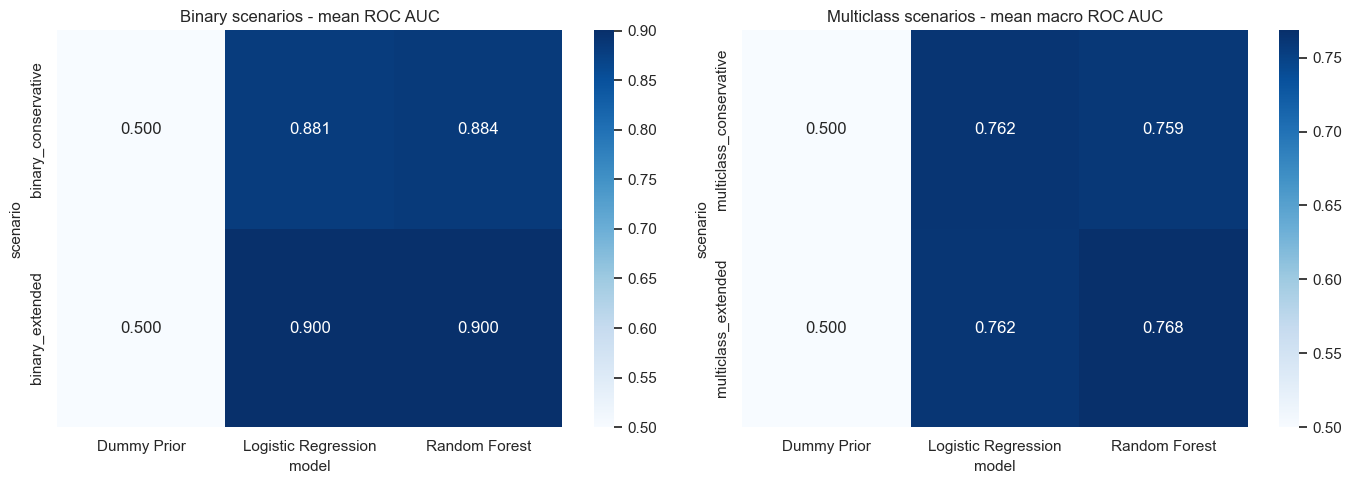

In [8]:
binary_heatmap = binary_summary.pivot(index="scenario", columns="model", values="roc_auc_mean")
multiclass_heatmap = multiclass_summary.pivot(index="scenario", columns="model", values="roc_auc_ovr_macro_mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(binary_heatmap, annot=True, cmap="Blues", fmt=".3f", ax=axes[0])
axes[0].set_title("Binary scenarios - mean ROC AUC")

sns.heatmap(multiclass_heatmap, annot=True, cmap="Blues", fmt=".3f", ax=axes[1])
axes[1].set_title("Multiclass scenarios - mean macro ROC AUC")
plt.tight_layout()


## 8. Analyse AIC / BIC pour les modeles logistiques

Les modeles logistiques jouent ici un double role :
- ils servent de baseline interpretable en validation croisee ;
- ils permettent aussi une comparaison par criteres d'information.

Un `BIC` plus faible indique un meilleur compromis entre adequation au jeu de donnees et parcimonie du modele. Encore une fois, on compare `BIC` **au sein d'un meme type de cible**.


In [9]:
logistic_info_rows = [compute_logistic_information_criteria(modeling_df, scenario_config) for scenario_config in scenario_configs]
logistic_info = pd.DataFrame(logistic_info_rows)

logistic_info["delta_bic_within_task"] = logistic_info.groupby("task_type")["bic"].transform(lambda series: series - series.min())
logistic_info["delta_aic_within_task"] = logistic_info.groupby("task_type")["aic"].transform(lambda series: series - series.min())

display(logistic_info.sort_values(["task_type", "bic"]))


,scenario,task_type,target,model,n_obs,transformed_feature_count,n_parameters,log_likelihood,aic,bic,delta_bic_within_task,delta_aic_within_task
0,binary_conservative,binary,target_binary,Logistic Regression,918,18,19,-383.3000,804.6000,896.2218,0.0000,63.6641
1,binary_extended,binary,target_binary,Logistic Regression,918,34,35,-335.4680,740.9359,909.7128,13.4911,0.0000
2,multiclass_conservative,multiclass,num,Logistic Regression,918,18,76,-974.9037,"2,101.8074","2,468.2944",0.0000,11.2125
3,multiclass_extended,multiclass,num,Logistic Regression,918,34,140,-905.2975,"2,090.5949","2,765.7025",297.4082,0.0000


## 9. Diagnostics detailes sur les meilleurs modeles

On extrait ensuite le meilleur couple `scenario x modele` pour la cible binaire et pour la cible multiclasse, sur la base de la metrique principale (`ROC AUC`). Les diagnostics suivants reposent sur les predictions out-of-fold, donc sur des observations non vues par le modele durant l'entrainement du fold correspondant.


In [10]:
best_binary_row = binary_summary.iloc[0]
best_multiclass_row = multiclass_summary.iloc[0]

best_binary_key = (best_binary_row["scenario"], best_binary_row["model"])
best_multiclass_key = (best_multiclass_row["scenario"], best_multiclass_row["model"])

best_binary_artifact = oof_artifacts[best_binary_key]
best_multiclass_artifact = oof_artifacts[best_multiclass_key]

display(pd.DataFrame([best_binary_row]))
display(pd.DataFrame([best_multiclass_row]))


,scenario,task_type,target,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,log_loss_mean,log_loss_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,roc_auc_ovr_macro_mean,roc_auc_ovr_macro_std,roc_auc_ovr_weighted_mean,roc_auc_ovr_weighted_std,f1_macro_mean,f1_macro_std
4,binary_extended,binary,target_binary,Logistic Regression,0.8236,0.0301,0.8204,0.0297,0.3994,0.0275,0.9002,0.0149,0.9094,0.0173,0.8420,0.0280,NaN,NaN,NaN,NaN,NaN,NaN


,scenario,task_type,target,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,log_loss_mean,log_loss_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,roc_auc_ovr_macro_mean,roc_auc_ovr_macro_std,roc_auc_ovr_weighted_mean,roc_auc_ovr_weighted_std,f1_macro_mean,f1_macro_std
11,multiclass_extended,multiclass,num,Random Forest,0.5349,0.0181,0.3306,0.0176,1.0951,0.0274,NaN,NaN,NaN,NaN,NaN,NaN,0.7684,0.0117,0.8059,0.0115,0.3208,0.0185


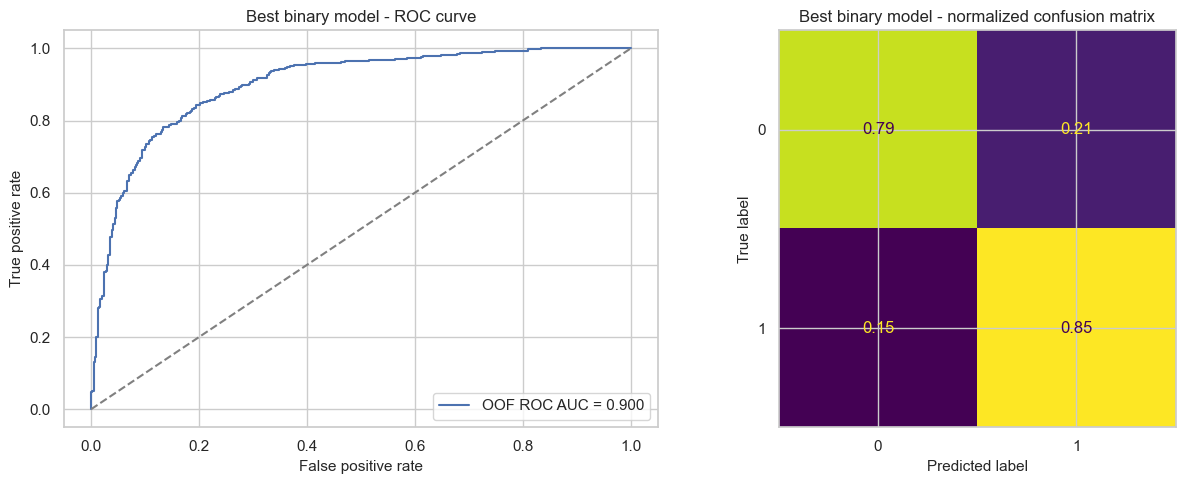

In [11]:
binary_true = best_binary_artifact["true"]
binary_pred = best_binary_artifact["pred"]
binary_labels = best_binary_artifact["labels"]
binary_positive_index = list(binary_labels).index(1)
binary_proba = best_binary_artifact["proba"][:, binary_positive_index]

fpr, tpr, _ = roc_curve(binary_true, binary_proba)
binary_auc = roc_auc_score(binary_true, binary_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, label=f"OOF ROC AUC = {binary_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("Best binary model - ROC curve")
axes[0].legend(loc="lower right")

ConfusionMatrixDisplay.from_predictions(binary_true, binary_pred, ax=axes[1], normalize="true", colorbar=False)
axes[1].set_title("Best binary model - normalized confusion matrix")
plt.tight_layout()


In [12]:
def safe_binary_auc(y_true, y_score):
    unique_values = np.unique(y_true)
    if len(unique_values) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


binary_source_diag = pd.DataFrame({
    "source": best_binary_artifact["source"],
    "y_true": binary_true,
    "y_pred": binary_pred,
    "y_score": binary_proba,
})

binary_source_summary = binary_source_diag.groupby("source").apply(
    lambda group: pd.Series({
        "n_obs": len(group),
        "positive_rate": group["y_true"].mean(),
        "roc_auc": safe_binary_auc(group["y_true"], group["y_score"]),
        "accuracy": accuracy_score(group["y_true"], group["y_pred"]),
        "balanced_accuracy": balanced_accuracy_score(group["y_true"], group["y_pred"]),
    })
).reset_index()

display(binary_source_summary)


,source,n_obs,positive_rate,roc_auc,accuracy,balanced_accuracy
0,cleveland,303.0000,0.4587,0.9058,0.8284,0.8272
1,hungarian,293.0000,0.3618,0.9004,0.8430,0.8259
2,switzerland,123.0000,0.9350,0.6967,0.9187,0.6076
3,va,199.0000,0.7437,0.7230,0.7286,0.6055


,class,ovr_auc
0,0,0.9035
1,1,0.6922
2,2,0.7427
3,3,0.7458
4,4,0.7518


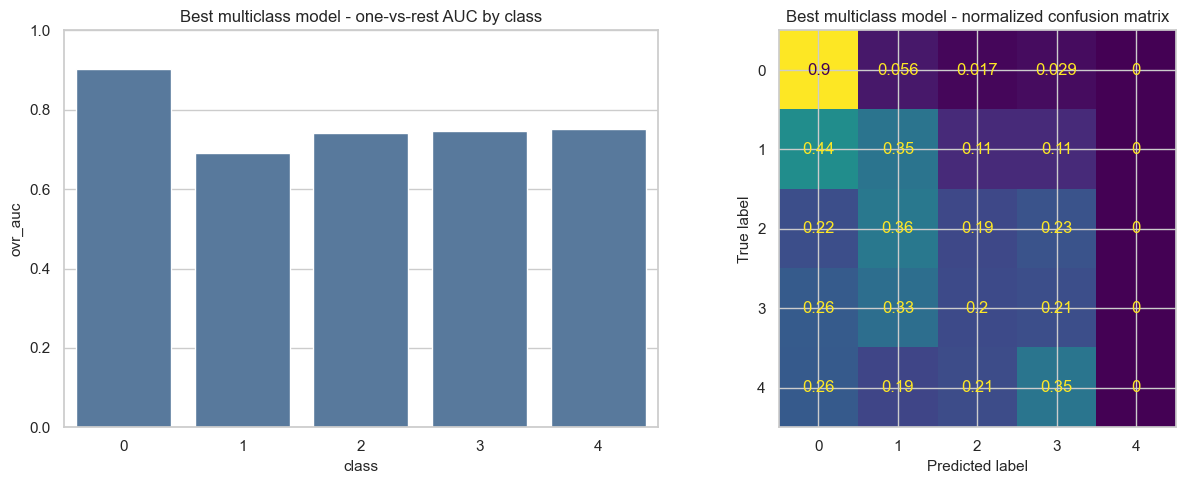

In [13]:
multiclass_true = best_multiclass_artifact["true"]
multiclass_pred = best_multiclass_artifact["pred"]
multiclass_labels = best_multiclass_artifact["labels"]
multiclass_proba = best_multiclass_artifact["proba"]

per_class_auc_rows = []
for class_index, class_value in enumerate(multiclass_labels):
    class_auc = roc_auc_score((multiclass_true == class_value).astype(int), multiclass_proba[:, class_index])
    per_class_auc_rows.append({
        "class": class_value,
        "ovr_auc": class_auc,
    })

per_class_auc = pd.DataFrame(per_class_auc_rows)
display(per_class_auc)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=per_class_auc, x="class", y="ovr_auc", color="#4C78A8", ax=axes[0])
axes[0].set_title("Best multiclass model - one-vs-rest AUC by class")
axes[0].set_ylim(0, 1)

ConfusionMatrixDisplay.from_predictions(multiclass_true, multiclass_pred, ax=axes[1], normalize="true", colorbar=False)
axes[1].set_title("Best multiclass model - normalized confusion matrix")
plt.tight_layout()


In [14]:
multiclass_source_diag = pd.DataFrame({
    "source": best_multiclass_artifact["source"],
    "y_true": multiclass_true,
    "y_pred": multiclass_pred,
})

multiclass_source_summary = multiclass_source_diag.groupby("source").apply(
    lambda group: pd.Series({
        "n_obs": len(group),
        "accuracy": accuracy_score(group["y_true"], group["y_pred"]),
        "balanced_accuracy": balanced_accuracy_score(group["y_true"], group["y_pred"]),
        "f1_macro": f1_score(group["y_true"], group["y_pred"], average="macro"),
    })
).reset_index()

display(multiclass_source_summary)


,source,n_obs,accuracy,balanced_accuracy,f1_macro
0,cleveland,303.0000,0.5611,0.2546,0.2406
1,hungarian,293.0000,0.6792,0.3422,0.3422
2,switzerland,123.0000,0.3821,0.3017,0.2653
3,va,199.0000,0.3769,0.3100,0.2953


## 10. Lecture des resultats et recommandation

Cette section doit etre lue en croisant plusieurs niveaux d'information.

### 1. Choix de la cible

Comparer d'abord les deux classements globaux :
- pour le **binaire**, regarder en priorite `roc_auc_mean`, `average_precision_mean` et `log_loss_mean` ;
- pour le **multiclasse**, regarder `roc_auc_ovr_macro_mean`, `roc_auc_ovr_weighted_mean`, `f1_macro_mean` et `log_loss_mean`.

Si la degradation du scenario multiclasse est moderee, alors il reste defendable pedagogiquement car il respecte mieux la cible originale. Si au contraire l'ecart avec le binaire devient trop fort, le binaire peut etre retenu comme scenario principal et le multiclasse conserve comme analyse complementaire.

### 2. Choix du jeu de variables

Comparer ensuite `conservative` et `extended` a l'interieur d'un meme type de cible.
- Si le scenario **etendu** apporte un gain net en AUC sans trop degrader le `log_loss` ni le `BIC`, alors les variables `slope`, `ca` et `thal` meritent d'etre conservees malgre leur difficulte.
- Si le gain est faible ou instable, le scenario **conservateur** est preferable car il repose sur des variables mieux renseignees et sera plus defendable en soutenance.

### 3. Role du BIC

Le `BIC` est surtout utile pour les modeles logistiques. Il ne dit pas tout sur la performance predictive, mais il renseigne sur le compromis entre qualite d'ajustement et complexite. Un scenario etendu qui ameliore tres peu l'AUC tout en augmentant fortement le `BIC` n'est pas un bon compromis.

### 4. Robustesse selon la source

Les tableaux par `source` permettent enfin de verifier si le meilleur scenario global reste coherent quand on regarde separement Cleveland, Hungary, Switzerland et VA. C'est un point important, car l'EDA a deja montre que les distributions sont tres heterogenes selon les hopitaux.


## 11. Conclusion operationnelle

A l'issue de ce notebook, vous devez pouvoir choisir de facon argumentee :
- une **cible principale** (`multiclasse` ou `binaire`) ;
- un **jeu de variables principal** (`conservateur` ou `etendu`) ;
- un **modele de reference** (logistique interpretable ou modele non lineaire plus performant).

Ce choix pourra ensuite etre reporte dans le README et dans la soutenance, avec une justification claire basee a la fois sur l'EDA, la validation croisee, et les criteres d'information.
